# 🧠 Notebook 3 — Feedforward Neural Network (FNN)
**Dataset:** Stellar Classification (SDSS)

This notebook covers:
1. FNN architecture with Dropout & L2 regularisation
2. Training with EarlyStopping & ReduceLROnPlateau
3. Training / Validation loss curves
4. Evaluation: accuracy, precision, recall, F1
5. Confusion matrix
6. Multi-class ROC curves (AUC per class)


## 0. Setup — Load Preprocessed Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, time
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from warnings import filterwarnings
filterwarnings('ignore')

with open('data/splits.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

with open('data/encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

class_names = encoder.classes_
num_classes = len(class_names)
print("Data loaded. Classes:", class_names)
print("Input features:", X_train.shape[1])


Data loaded. Classes: ['GALAXY' 'QSO' 'STAR']
Input features: 8


## 1. FNN Architecture

### Design choices
| Component | Rationale |
|---|---|
| L2 regularisation | Penalises large weights → reduces overfitting |
| Dropout (0.3) | Randomly deactivates 30% of neurons per step |
| He initialisation | Optimal for ReLU — avoids vanishing gradients |
| Softmax output | Outputs a probability distribution over 3 classes |
| `sparse_categorical_crossentropy` | Works directly with integer class labels |


In [2]:
DROPOUT_RATE = 0.3
L2_REG       = 0.001
EPOCHS       = 15
BATCH_SIZE   = 64

model_fnn = models.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(L2_REG),
                 input_shape=(X_train.shape[1],)),
    layers.Dropout(DROPOUT_RATE),

    layers.Dense(32, activation='relu',
                 kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(L2_REG)),
    layers.Dropout(DROPOUT_RATE),

    layers.Dense(16, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model_fnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_fnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,235 (12.64 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Training

In [3]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3)
]

start_fnn = time.time()
history = model_fnn.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)
fnn_time = time.time() - start_fnn

print(f"\nTraining time: {fnn_time:.2f}s")


Epoch 1/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7215 - loss: 0.7052 - val_accuracy: 0.8653 - val_loss: 0.4148 - learning_rate: 5.0000e-04
Epoch 2/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8601 - loss: 0.4273 - val_accuracy: 0.9028 - val_loss: 0.3249 - learning_rate: 5.0000e-04
Epoch 3/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8945 - loss: 0.3530 - val_accuracy: 0.9272 - val_loss: 0.2696 - learning_rate: 5.0000e-04
Epoch 4/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9193 - loss: 0.2990 - val_accuracy: 0.9434 - val_loss: 0.2337 - learning_rate: 5.0000e-04
Epoch 5/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9321 - loss: 0.2626 - val_accuracy: 0.9442 - val_loss: 0.2130 - learning_rate: 5.0000e-04
Epoch 6/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9392 - loss: 0.2395 - val_accuracy: 0.9520 - val_loss: 0.1931 - learning_rate: 5.0000e-04
Epoch 7/15
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

## 3. Training vs Validation Loss

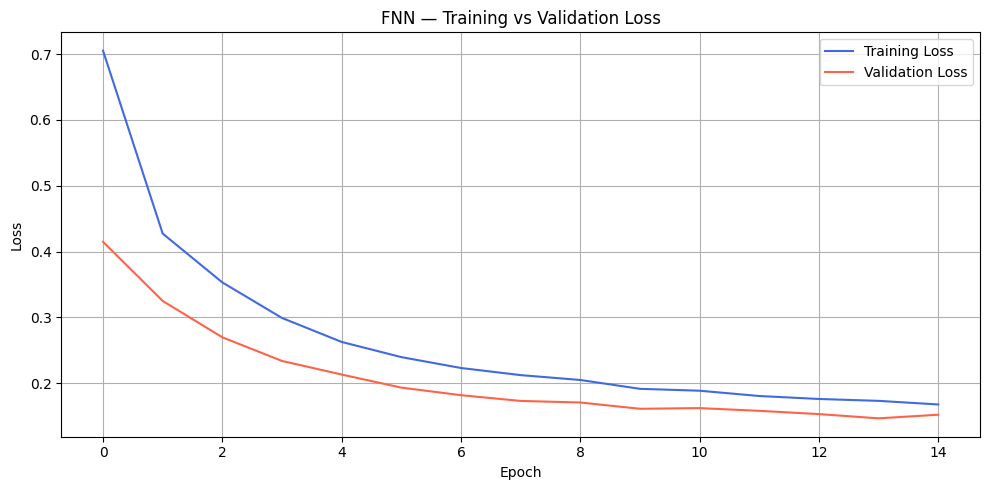

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato')
plt.title('FNN — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretation:**
A rapidly decreasing loss in early epochs followed by stabilisation indicates
good convergence. A moderate gap between training (~0.2) and validation (~0.3) loss
reflects controlled overfitting thanks to Dropout and L2 regularisation.
If the gap is large, consider increasing Dropout or adding more data.


## 4. Model Evaluation

In [5]:
test_loss, test_acc = model_fnn.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Test Loss    : 0.1486
Test Accuracy: 96.15%


In [6]:
y_pred_proba = model_fnn.predict(X_test)
y_pred_fnn   = np.argmax(y_pred_proba, axis=1)

print("\nDetailed Metrics:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_fnn):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_fnn, average='weighted'):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_fnn, average='weighted'):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_fnn, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_fnn, target_names=class_names))


515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Detailed Metrics:
  Accuracy : 0.9615
  Precision: 0.9622
  Recall   : 0.9615
  F1-Score : 0.9614

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.93      0.96      0.95      5651
         QSO       0.98      0.92      0.95      5142
        STAR       0.98      1.00      0.99      5684

    accuracy                           0.96     16477
   macro avg       0.96      0.96      0.96     16477
weighted avg       0.96      0.96      0.96     16477



## 5. Confusion Matrix

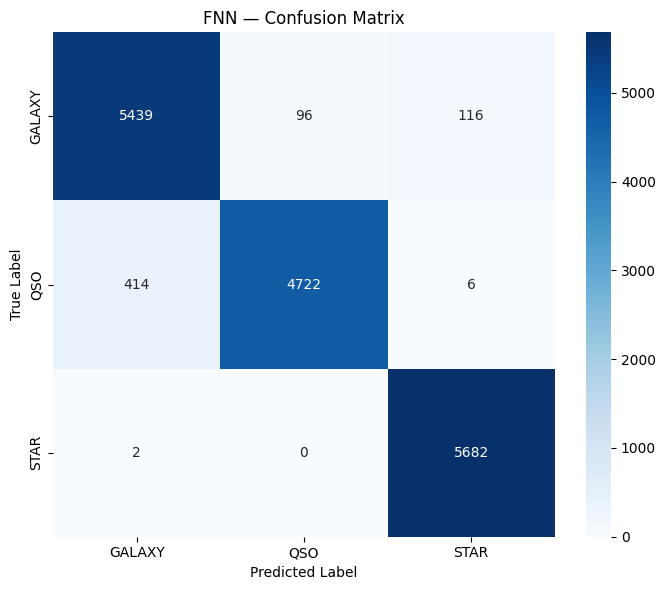

In [7]:
cm_fnn = confusion_matrix(y_test, y_pred_fnn)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_fnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('FNN — Confusion Matrix')
plt.tight_layout()
plt.show()


## 6. Multi-Class ROC Curves

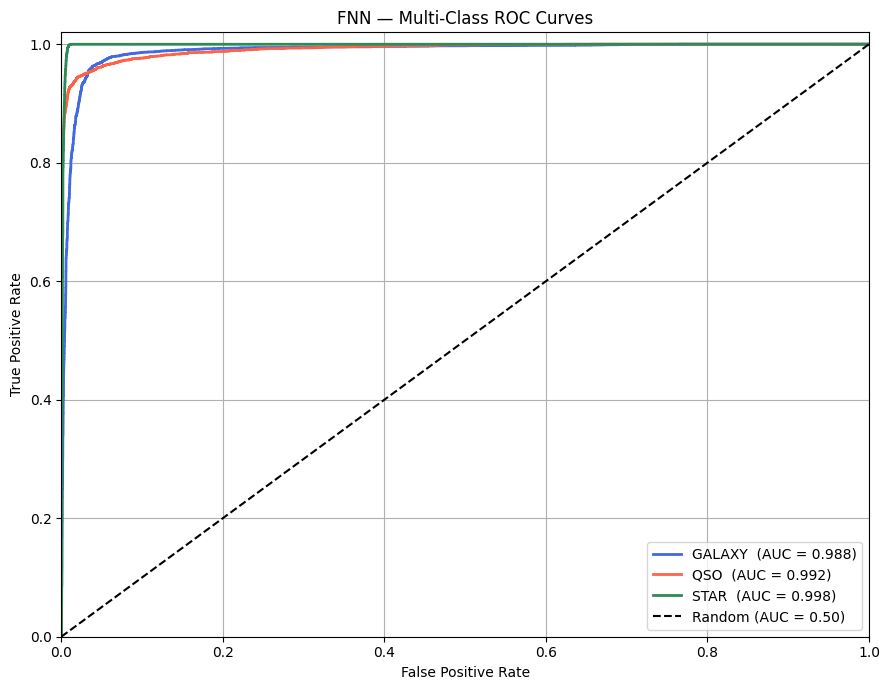

In [8]:
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

fpr, tpr, roc_auc_dict = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc_dict[i]   = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 7))
colors = ['royalblue', 'tomato', 'seagreen']
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{class_names[i]}  (AUC = {roc_auc_dict[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.50)')
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FNN — Multi-Class ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


**AUC Interpretation:**
- 0.90–1.00 = Excellent  
- 0.80–0.90 = Good  
- < 0.70    = Poor  

An AUC close to 1.0 for all three classes indicates strong discriminative
ability between GALAXY, QSO, and STAR.


## 7. Save Predictions & Model

In [9]:
import os
os.makedirs('predictions', exist_ok=True)
os.makedirs('models', exist_ok=True)

with open('predictions/fnn.pkl', 'wb') as f:
    pickle.dump({
        'y_pred_fnn':   y_pred_fnn,
        'y_pred_proba': y_pred_proba,
        'y_test':       y_test,
        'fnn_time':     fnn_time
    }, f)

model_fnn.save('models/fnn_model.keras')
print("Model saved to models/fnn_model.keras")
print("Predictions saved to predictions/fnn.pkl")


Model saved to models/fnn_model.keras
Predictions saved to predictions/fnn.pkl
